In [1]:
import pandas as pd
import numpy as np
import sys, os, re, random

sys.path.append(os.path.join('..', 'ml-backend'))
from utils.feature_extractor import extract_features, extract_features_batch

random.seed(42)
np.random.seed(42)
print("Import berhasil!")

Import berhasil!


In [2]:
df_phishing_raw = pd.read_csv('../dataset/phishing_urls.csv')
print("Jumlah baris:", len(df_phishing_raw))
print("Kolom:", df_phishing_raw.columns.tolist())
print(df_phishing_raw.head(3))

Jumlah baris: 57103
Kolom: ['phish_id', 'url', 'phish_detail_url', 'submission_time', 'verified', 'verification_time', 'online', 'target']
   phish_id                                        url  \
0   9397334     http://allegrolokalne.pl-590120421.lol   
1   9397332           http://allegro.pl-5903241241.lol   
2   9397331  http://allegro-lokalnie.pl-5903241241.lol   

                                    phish_detail_url  \
0  http://www.phishtank.com/phish_detail.php?phis...   
1  http://www.phishtank.com/phish_detail.php?phis...   
2  http://www.phishtank.com/phish_detail.php?phis...   

             submission_time verified          verification_time online  \
0  2026-04-19T07:56:30+00:00      yes  2026-04-19T08:03:15+00:00    yes   
1  2026-04-19T07:56:25+00:00      yes  2026-04-19T08:03:15+00:00    yes   
2  2026-04-19T07:56:15+00:00      yes  2026-04-19T08:03:15+00:00    yes   

    target  
0  Allegro  
1  Allegro  
2  Allegro  


In [3]:
df_phishing = pd.DataFrame({
    'url'  : df_phishing_raw['url'],
    'label': 1
})
df_phishing = df_phishing.dropna().drop_duplicates()
df_phishing = df_phishing.head(5000)
print(f"Dataset phishing: {len(df_phishing)} URL")

Dataset phishing: 5000 URL


In [ ]:
df_alexa_raw = pd.read_csv(
    '../dataset/top-1m.csv',
    header=None,
    names=['rank', 'domain']
)

REALISTIC_PATHS = [
    '',
    '/about',
    '/contact',
    '/products',
    '/search',
    '/home',
    '/news',
    '/article',
    '/blog',
    '/faq',
    '/help',
    '/login',
    '/register',
    '/profile',
    '/settings',
    '/dashboard',
]

REALISTIC_QUERIES = [
    '',
    '?page=1',
    '?lang=id',
    '?ref=home',
    '?q=berita+terbaru',
    '?category=teknologi',
    '?id=123',
    '?tab=overview',
    '?sort=desc',
    '?utm_source=google',
]

def enrich_legitimate_url(domain):
    scheme = 'https://'
    
    if random.random() < 0.30:
        return f"{scheme}{domain}"
    
    path  = random.choice(REALISTIC_PATHS)
    query = random.choice(REALISTIC_QUERIES)
    
    return f"{scheme}{domain}{path}{query}"

df_legitimate = pd.DataFrame({
    'url'  : [enrich_legitimate_url(d) for d in df_alexa_raw['domain'].head(6000)],
    'label': 0
})

df_legitimate = df_legitimate.dropna().drop_duplicates()
df_legitimate = df_legitimate.head(5000)

print(f"Dataset legitimate: {len(df_legitimate)} URL")
print("\nContoh URL (setelah enrichment):")
for url in df_legitimate['url'].sample(5).values:
    print(f"  {url}")

Dataset legitimate: 5000 URL

Contoh URL (setelah enrichment):
  https://blackboard.com
  https://list.ru
  https://topit.me
  https://grooveshark.com/profile?id=123
  https://123rf.com/home?lang=id


In [ ]:
# Keyword inti judol
KEYWORD_SLOT = [
    'slotgacor', 'slot-gacor', 'slot777', 'slot88', 'slotmaxwin',
    'slot-maxwin', 'bocoran-slot', 'rtp-slot', 'slot-online',
    'slot-pragmatic', 'slot-pgsoft', 'slot-zeus', 'gates-of-olympus',
    'sweet-bonanza', 'mahjong-ways', 'starlight-princess',
    'slot-scatter', 'gacor-slot', 'slot-gacor-hari-ini',
]

KEYWORD_TOGEL = [
    'togel', 'togelonline', 'togel4d', 'bandar-togel', 'agen-togel',
    'togel-singapore', 'togel-hongkong', 'prediksi-togel',
    'bocoran-togel', 'angka-jitu', 'live-draw-togel', 'result-togel',
]

KEYWORD_CASINO = [
    'casino-online', 'live-casino', 'casino-indonesia',
    'baccarat-online', 'roulette-online', 'casino-terpercaya',
]

KEYWORD_POKER = [
    'poker-online', 'poker-uang-asli', 'dominoqq', 'bandarq',
    'ceme-online', 'idn-poker', 'capsa-susun', 'sakong-online',
]

KEYWORD_SBOBET = [
    'sbobet', 'agen-sbobet', 'judi-bola', 'taruhan-bola',
    'mix-parlay', 'bandar-bola', 'bola-online', 'sportsbook',
]

KEYWORD_UMUM = [
    'judi-online', 'agen-judi', 'bandar-judi', 'bonus-new-member',
    'freebet', 'rtp-live', 'rtp-gacor', 'scatter-hitam',
    'pola-gacor', 'maxwin', 'judol', 'daftar-judi',
]

TLD_JUDOL = ['.com', '.net', '.xyz', '.online', '.site',
             '.info', '.club', '.live', '.top', '.vip']

SUFFIX    = ['', '88', '77', '99', '168', '365', '2024', '4d', '138', 'pro']
PROTOCOL  = ['http://', 'https://']

JUDOL_PATHS = [
    '',
    '/daftar',
    '/login',
    '/promo',
    '/promo/bonus-new-member',
    '/game/slot',
    '/game/live-casino',
    '/deposit',
    '/withdraw',
    '/link-alternatif',
    '/daftar?ref=telegram',
    '/promo?bonus=100',
]

JUDOL_SUBDOMAINS = [
    '', 'www', 'link', 'daftar', 'login', 'promo',
    'alternatif', 'main', 'play', 'game',
]

def generate_realistic_gambling_urls(keywords, n_target=1500, seed=42):
    # Generate URL judol
    random.seed(seed)
    urls = set()

    for kw in keywords:
        for tld in TLD_JUDOL:
            for proto in PROTOCOL:
                # Template 1: bare domain
                urls.add(f"{proto}{kw}{tld}")

                # Template 2: dengan suffix angka
                for suffix in random.sample(SUFFIX, 3):
                    urls.add(f"{proto}{kw}{suffix}{tld}")

                # Template 3: dengan subdomain
                sub = random.choice(JUDOL_SUBDOMAINS[1:])
                urls.add(f"{proto}{sub}.{kw}{tld}")

                # Template 4: dengan path
                path = random.choice(JUDOL_PATHS[1:])
                urls.add(f"{proto}{kw}{tld}{path}")

                # Template 5: kombinasi subdomain + path
                sub  = random.choice(JUDOL_SUBDOMAINS[1:])
                path = random.choice(JUDOL_PATHS[1:])
                urls.add(f"{proto}{sub}.{kw}{suffix}{tld}{path}")

    url_list = list(urls)
    random.shuffle(url_list)
    return url_list[:n_target]

# Generate semua kategori judol
urls_slot   = generate_realistic_gambling_urls(KEYWORD_SLOT,   n_target=1000, seed=42)
urls_togel  = generate_realistic_gambling_urls(KEYWORD_TOGEL,  n_target=900,  seed=43)
urls_casino = generate_realistic_gambling_urls(KEYWORD_CASINO, n_target=700,  seed=44)
urls_poker  = generate_realistic_gambling_urls(KEYWORD_POKER,  n_target=700,  seed=45)
urls_sbobet = generate_realistic_gambling_urls(KEYWORD_SBOBET, n_target=700,  seed=46)
urls_umum   = generate_realistic_gambling_urls(KEYWORD_UMUM,   n_target=1000, seed=47)

semua_url_judi = list(set(
    urls_slot + urls_togel + urls_casino +
    urls_poker + urls_sbobet + urls_umum
))
random.shuffle(semua_url_judi)
semua_url_judi = semua_url_judi[:5000]

df_gambling = pd.DataFrame({
    'url'  : semua_url_judi,
    'label': 2
})

print(f"Slot     : {len(urls_slot)} URL")
print(f"Togel    : {len(urls_togel)} URL")
print(f"Casino   : {len(urls_casino)} URL")
print(f"Poker    : {len(urls_poker)} URL")
print(f"Sbobet   : {len(urls_sbobet)} URL")
print(f"Umum     : {len(urls_umum)} URL")
print(f"\nTotal dipakai : {len(df_gambling)} URL judi")

print("\nContoh URL judi (lebih realistis):")
for url in df_gambling['url'].sample(8).values:
    print(f"  {url}")

Slot     : 1000 URL
Togel    : 900 URL
Casino   : 700 URL
Poker    : 700 URL
Sbobet   : 700 URL
Umum     : 1000 URL

Total dipakai : 5000 URL judi

Contoh URL judi (lebih realistis):
  https://alternatif.judi-online138.net/withdraw
  https://rtp-gacorpro.net
  http://slot-zeus.online
  http://promo.slot-gacor-hari-ini365.site/withdraw
  http://slot-gacor-hari-ini2024.info
  http://freebet88.net
  http://bandar-judi77.top
  http://bocoran-togel.vip


In [6]:
TARGET = 5000

df_phishing_balanced   = df_phishing.head(TARGET)
df_legitimate_balanced = df_legitimate.head(TARGET)
df_gambling_balanced   = df_gambling.head(TARGET)

df_all = pd.concat(
    [df_phishing_balanced, df_legitimate_balanced, df_gambling_balanced],
    ignore_index=True
)

df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total dataset : {len(df_all)} URL")
print(f"\nDistribusi label:")
counts = df_all['label'].value_counts().sort_index()
for label, count in counts.items():
    nama   = {0:'Aman', 1:'Phishing', 2:'Judi Online'}[label]
    persen = count / len(df_all) * 100
    bar    = '█' * int(persen / 2)
    print(f"  {nama:<12}: {count} ({persen:.1f}%) {bar}")

print("\n✅ Dataset seimbang! Masing-masing kelas ~33%")

Total dataset : 15000 URL

Distribusi label:
  Aman        : 5000 (33.3%) ████████████████
  Phishing    : 5000 (33.3%) ████████████████
  Judi Online : 5000 (33.3%) ████████████████

✅ Dataset seimbang! Masing-masing kelas ~33%


In [7]:
print("Memulai ekstraksi fitur (versi 2.1 dengan 27 fitur)...")

features_list = extract_features_batch(df_all['url'].tolist())
df_features   = pd.DataFrame(features_list)
df_features['label'] = df_all['label'].values

print(f"Selesai! Shape dataset: {df_features.shape}")
print(f"Jumlah fitur: {df_features.shape[1] - 1}")
print("\n3 baris pertama:")
print(df_features.head(3).to_string())

Memulai ekstraksi fitur (versi 2.1 dengan 27 fitur)...
Selesai! Shape dataset: (15000, 28)
Jumlah fitur: 27

3 baris pertama:
   url_length  has_https  dot_count  hyphen_count  at_count  double_slash  digit_count  domain_length  path_depth  has_query  has_suspicious_tld  has_ip  has_phishing_keyword  has_gambling_keyword  has_brand_spoofing  subdomain_length  subdomain_count  domain_entropy  special_chars  path_length  digit_ratio_url  has_port  has_redirect  consonant_ratio  query_length  query_params  has_fragment  label
0          37          1          2             3         0             0            0             19           0          0                   1       0                     0                     1                   0                 5                1          3.4316              0            0              0.0         0             0           0.5625             0             0             0      2
1          50          1          1             0         0         

In [ ]:
import matplotlib.pyplot as plt

label_names = {0: 'Aman', 1: 'Phishing', 2: 'Judi'}
colors      = {0: 'green', 1: 'red', 2: 'orange'}

# Statistik rata-rata per kelas
print("=== Rata-rata Fitur per Kelas ===")
fitur_cek = ['url_length', 'dot_count', 'domain_entropy',
             'has_https', 'has_suspicious_tld',
             'has_phishing_keyword', 'has_gambling_keyword',
             'subdomain_count', 'path_length']

for fitur in fitur_cek:
    print(f"\n{fitur}:")
    for label, nama in label_names.items():
        rata = df_features[df_features['label'] == label][fitur].mean()
        print(f"  {nama:<12}: {rata:.3f}")

print("\n✅ Jika nilai berbeda antar kelas → fitur berguna untuk ML")

=== Rata-rata Fitur per Kelas ===

url_length:
  Aman        : 31.935
  Phishing    : 45.090
  Judi        : 30.472

dot_count:
  Aman        : 1.099
  Phishing    : 1.932
  Judi        : 1.300

domain_entropy:
  Aman        : 2.423
  Phishing    : 2.709
  Judi        : 3.184

has_https:
  Aman        : 1.000
  Phishing    : 0.903
  Judi        : 0.506

has_suspicious_tld:
  Aman        : 0.000
  Phishing    : 0.071
  Judi        : 0.506

has_phishing_keyword:
  Aman        : 0.043
  Phishing    : 0.071
  Judi        : 0.060

has_gambling_keyword:
  Aman        : 0.004
  Phishing    : 0.003
  Judi        : 0.852

subdomain_count:
  Aman        : 0.098
  Phishing    : 0.744
  Judi        : 0.267

path_length:
  Aman        : 4.556
  Phishing    : 8.979
  Judi        : 3.196

✅ Jika nilai berbeda antar kelas → fitur berguna untuk ML


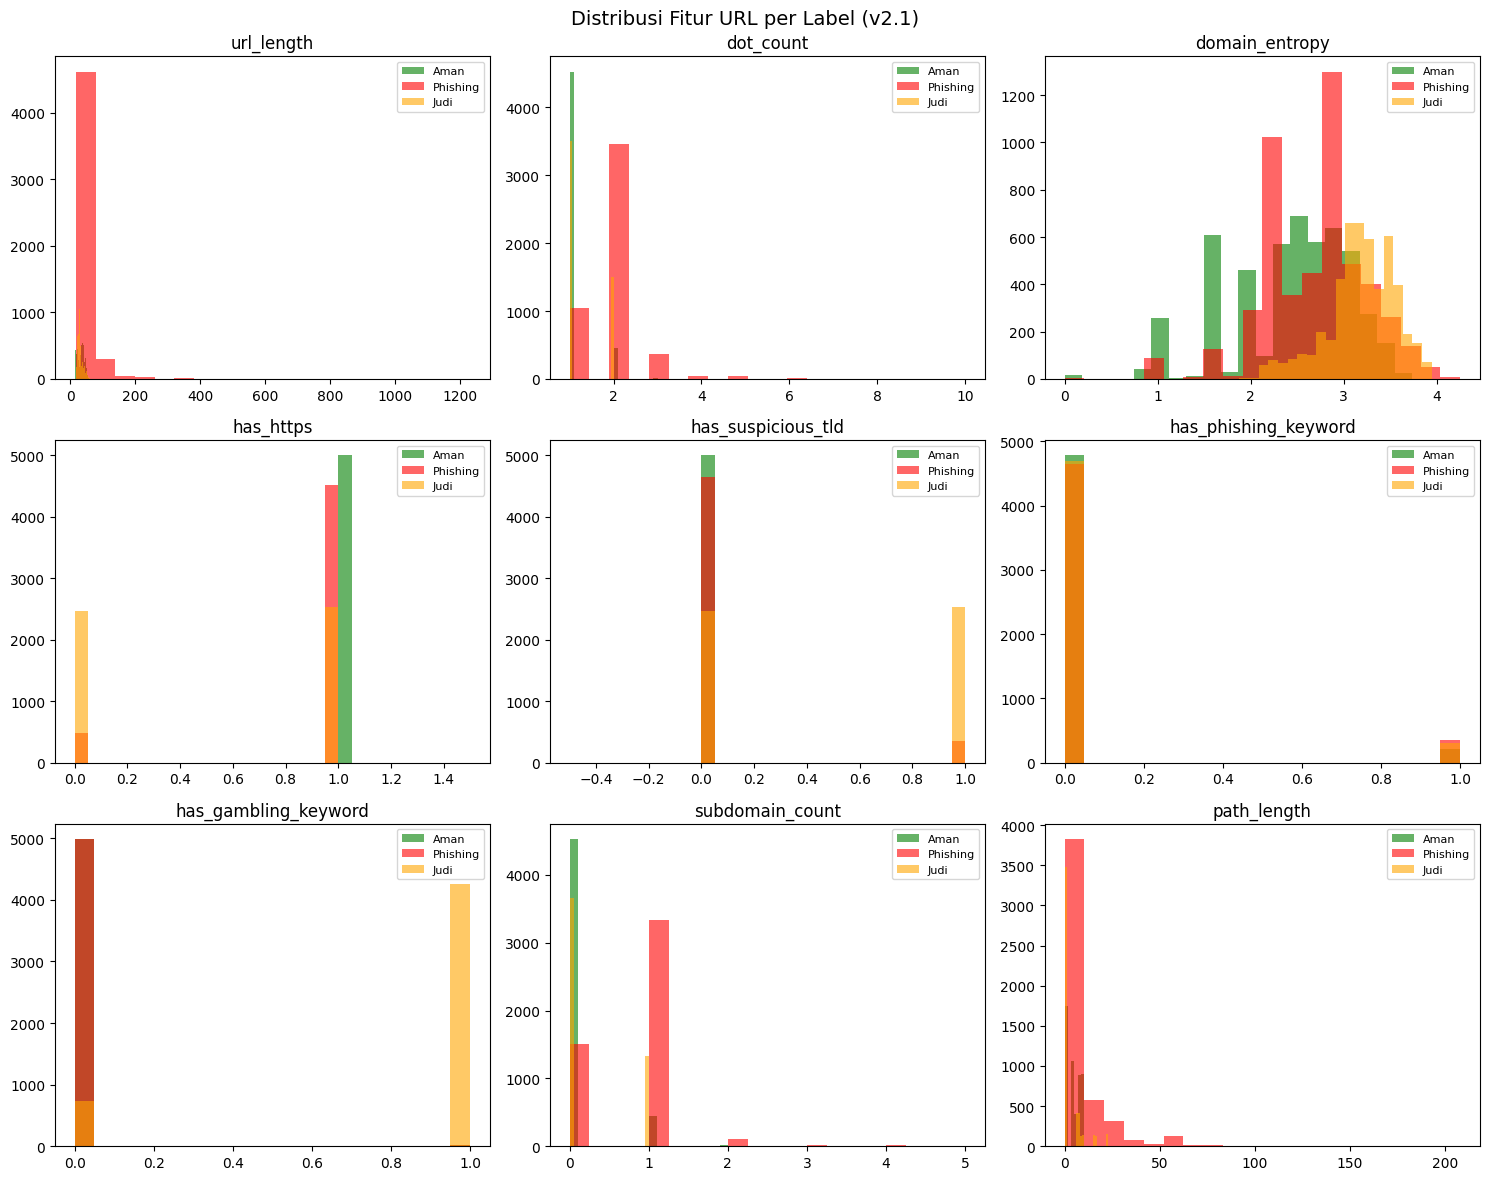

Grafik disimpan!


In [9]:
# Plot distribusi fitur
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribusi Fitur URL per Label (v2.1)', fontsize=14)

fitur_plot = ['url_length', 'dot_count', 'domain_entropy',
              'has_https', 'has_suspicious_tld', 'has_phishing_keyword',
              'has_gambling_keyword', 'subdomain_count', 'path_length']

for idx, fitur in enumerate(fitur_plot):
    ax = axes[idx // 3][idx % 3]
    for label, nama in label_names.items():
        data = df_features[df_features['label'] == label][fitur]
        ax.hist(data, alpha=0.6, label=nama, color=colors[label], bins=20)
    ax.set_title(fitur)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../dataset/feature_distribution_v21.png', dpi=100)
plt.show()
print("Grafik disimpan!")

In [10]:
df_features.to_csv('../ml-backend/data/features_dataset.csv', index=False)
print("Dataset berhasil disimpan ke ml-backend/data/features_dataset.csv!")
print(f"Total: {len(df_features)} baris, {len(df_features.columns)} kolom")
print(f"Fitur: {[c for c in df_features.columns if c != 'label']}")

Dataset berhasil disimpan ke ml-backend/data/features_dataset.csv!
Total: 15000 baris, 28 kolom
Fitur: ['url_length', 'has_https', 'dot_count', 'hyphen_count', 'at_count', 'double_slash', 'digit_count', 'domain_length', 'path_depth', 'has_query', 'has_suspicious_tld', 'has_ip', 'has_phishing_keyword', 'has_gambling_keyword', 'has_brand_spoofing', 'subdomain_length', 'subdomain_count', 'domain_entropy', 'special_chars', 'path_length', 'digit_ratio_url', 'has_port', 'has_redirect', 'consonant_ratio', 'query_length', 'query_params', 'has_fragment']
